In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [2]:
pip install pandas numpy scikit-learn xgboost lightgbm openpyxl joblib

✅ Библиотеки загружены
✅ Данные загружены. Размер: (3106, 11)
Цена: удалено 89, диапазон $24,506 – $249,900
Площадь: удалено 88, диапазон 27.3 – 110.0 м²
Комнаты: удалено 4, оставлены 1-4
Удалено выбросов: 181, осталось: 2925


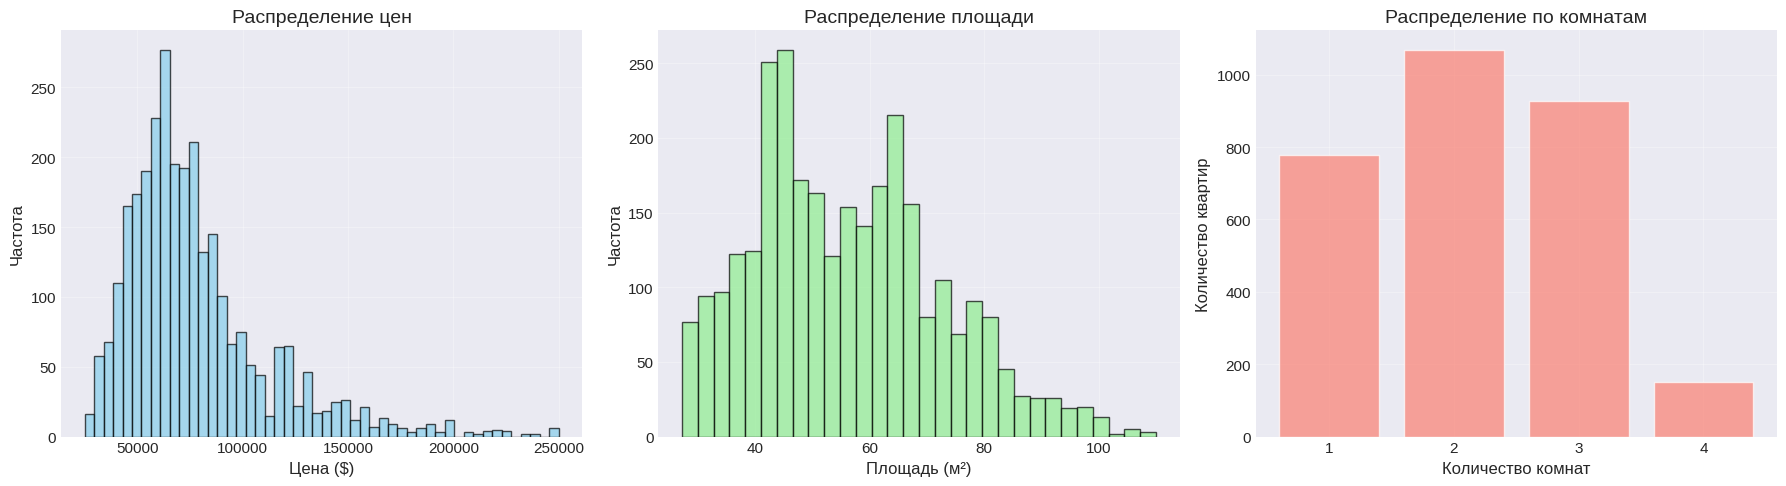

XGBoost: R²=0.9711, MAE=$2,572, MAPE=3.7%
Gradient Boosting: R²=0.9684, MAE=$3,231, MAPE=4.7%
LightGBM: R²=0.9454, MAE=$5,209, MAPE=7.2%
   XGBoost              Train R²=0.9996  Test R²=0.9711  Δ=0.0285  ✅ Норма
   Gradient Boosting    Train R²=0.9985  Test R²=0.9684  Δ=0.0301  ✅ Норма
   LightGBM             Train R²=0.9884  Test R²=0.9454  Δ=0.0431  ✅ Норма


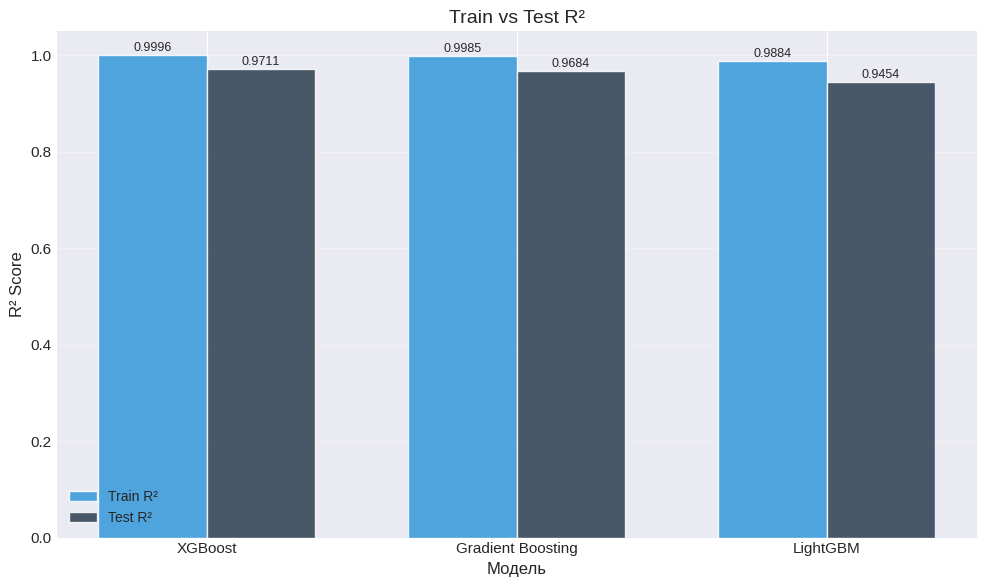

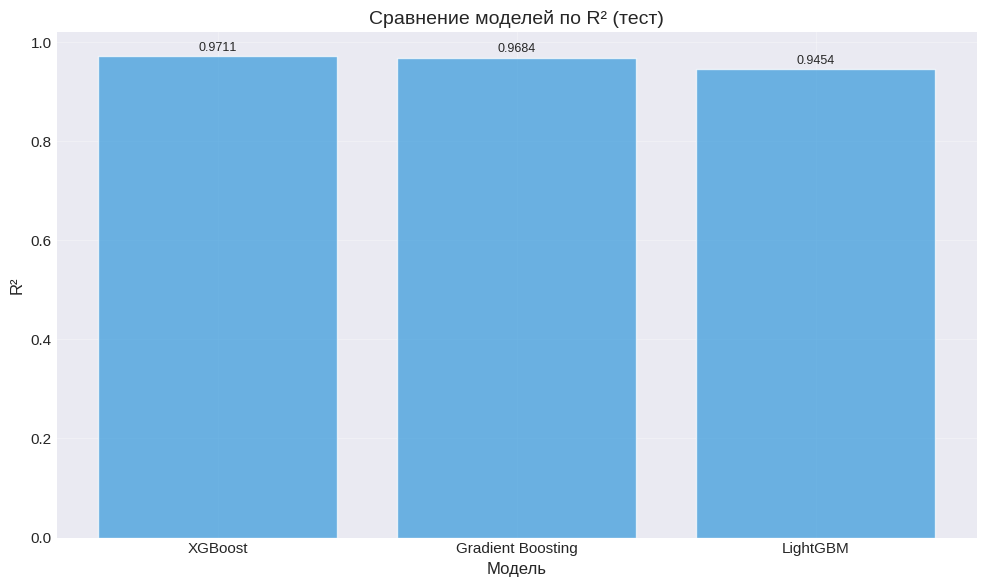

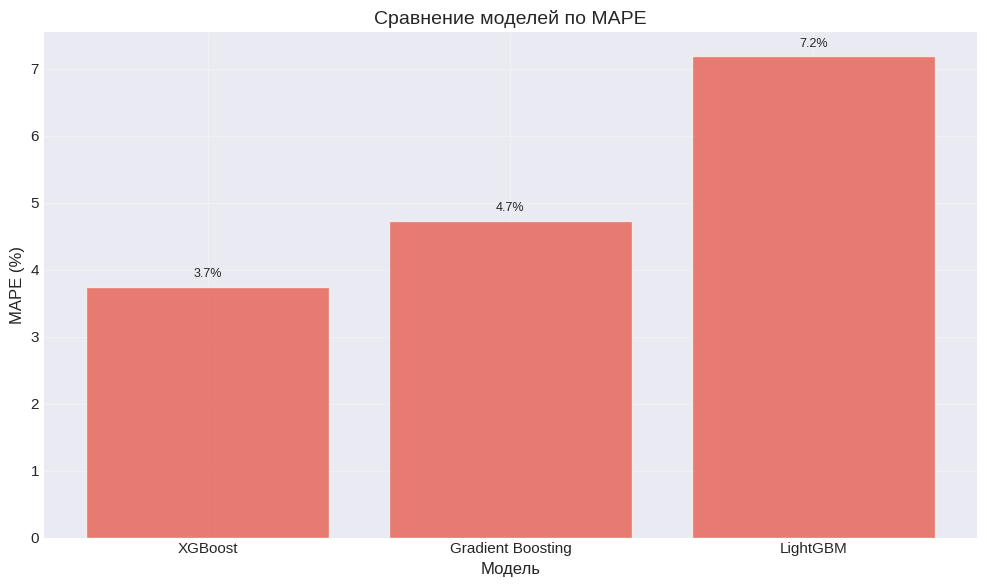

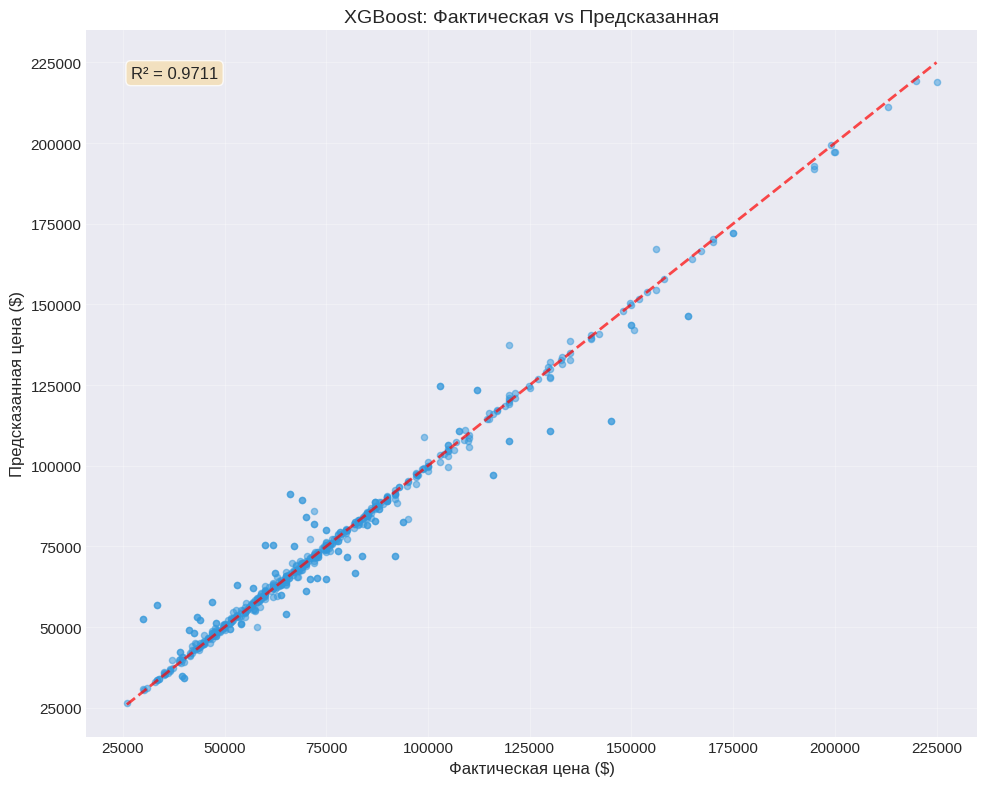

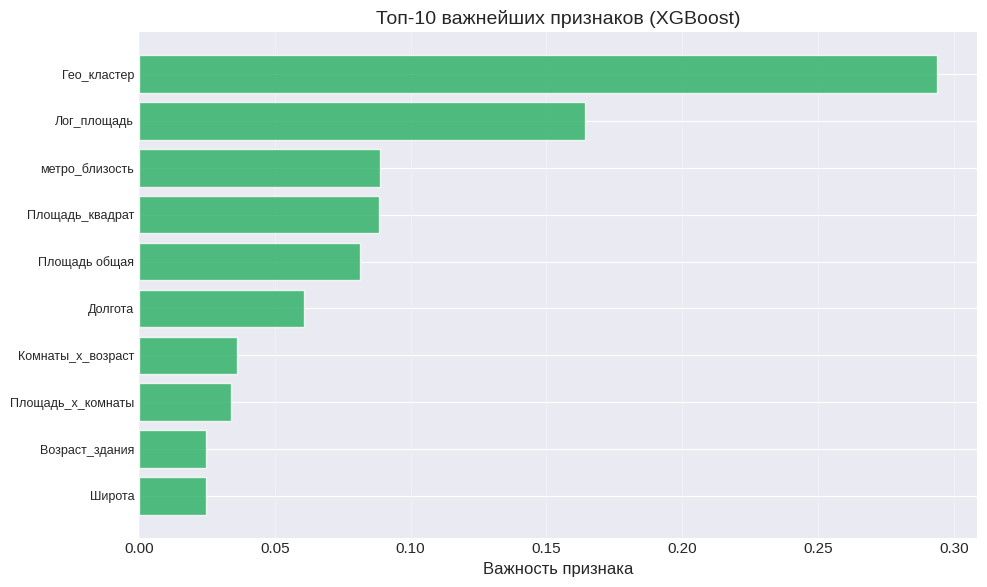

✅ Лучшая модель (XGBoost) сохранена в 'best_model.pkl'


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Библиотеки загружены")

try:
    df = pd.read_excel('flats_realtby.xlsx')
    print(f"✅ Данные загружены. Размер: {df.shape}")
except Exception as e:
    print(f"❌ Ошибка загрузки: {e}")
    raise

def clean_numeric(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    value_str = str(value).replace(' ', '').replace(',', '.')
    value_str = re.sub(r'[^\d\.\-]', '', value_str)
    try:
        return float(value_str)
    except:
        return np.nan

numeric_cols = ['Цена в $', 'Площадь общая', 'Площадь жилая', 'Количество комнат', 'Этаж', 'Год постройки']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

initial_len = len(df)

LOW_PERCENTILE = 0.01
HIGH_PERCENTILE = 0.98

def remove_outliers_percentile(df, column, low_p, high_p):
    lower = df[column].quantile(low_p)
    upper = df[column].quantile(high_p)
    mask = (df[column] >= lower) & (df[column] <= upper)
    removed = (~mask).sum()
    return df[mask], removed, lower, upper

df, rem_price, low_price, high_price = remove_outliers_percentile(df, 'Цена в $', LOW_PERCENTILE, HIGH_PERCENTILE)
print(f"Цена: удалено {rem_price}, диапазон ${low_price:,.0f} – ${high_price:,.0f}")

df, rem_area, low_area, high_area = remove_outliers_percentile(df, 'Площадь общая', LOW_PERCENTILE, HIGH_PERCENTILE)
print(f"Площадь: удалено {rem_area}, диапазон {low_area:.1f} – {high_area:.1f} м²")

MAX_ROOMS = 4
room_mask = df['Количество комнат'] <= MAX_ROOMS
rem_rooms = (~room_mask).sum()
df = df[room_mask]
print(f"Комнаты: удалено {rem_rooms}, оставлены 1-{MAX_ROOMS}")

total_removed = initial_len - len(df)
print(f"Удалено выбросов: {total_removed}, осталось: {len(df)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df['Цена в $'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Цена ($)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение цен')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Площадь общая'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_xlabel('Площадь (м²)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение площади')
axes[1].grid(True, alpha=0.3)

room_counts = df['Количество комнат'].value_counts().sort_index()
axes[2].bar(room_counts.index, room_counts.values, alpha=0.7, color='salmon')
axes[2].set_xlabel('Количество комнат')
axes[2].set_ylabel('Количество квартир')
axes[2].set_title('Распределение по комнатам')
axes[2].set_xticks(room_counts.index)
axes[2].set_xticklabels([int(x) for x in room_counts.index])
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

current_year = datetime.now().year
df['Возраст_здания'] = current_year - df['Год постройки'].clip(lower=1900, upper=current_year)
df['Соотношение_жилой_площади'] = df['Площадь жилая'] / df['Площадь общая'].clip(lower=1)
df['Плотность_комнат'] = df['Количество комнат'] / df['Площадь общая'].clip(lower=1)
df['Высокий_этаж'] = (df['Этаж'] > 5).astype(int)
df['Низкий_этаж'] = (df['Этаж'] <= 2).astype(int)
df['Новостройка'] = (df['Возраст_здания'] <= 5).astype(int)
df['Старое_здание'] = (df['Возраст_здания'] > 30).astype(int)
df['Площадь_x_комнаты'] = df['Площадь общая'] * df['Количество комнат']
df['Площадь_квадрат'] = df['Площадь общая'] ** 2
df['Лог_площадь'] = np.log(df['Площадь общая'].clip(lower=1))
df['Площадь_x_возраст'] = df['Площадь общая'] * df['Возраст_здания']
df['Комнаты_x_возраст'] = df['Количество комнат'] * df['Возраст_здания']

def parse_coordinates(coord_str):
    try:
        if isinstance(coord_str, str):
            coord_str = coord_str.strip('()[]{}')
            parts = coord_str.split(',')
            if len(parts) >= 2:
                lat = float(parts[0].strip())
                lon = float(parts[1].strip())
                if 51.0 <= lat <= 57.0 and 23.0 <= lon <= 33.0:
                    return lat, lon
    except:
        pass
    return np.nan, np.nan

coords = df['Координаты'].apply(parse_coordinates)
df['Широта'] = coords.apply(lambda x: x[0])
df['Долгота'] = coords.apply(lambda x: x[1])

valid_coords = df[['Широта', 'Долгота']].dropna()
if len(valid_coords) > 50:
    coords_scaled = (valid_coords - valid_coords.mean()) / valid_coords.std()
    kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(coords_scaled)
    df.loc[valid_coords.index, 'Гео_кластер'] = clusters
else:
    df['Гео_кластер'] = 0

def extract_advanced_features(text):
    if not isinstance(text, str) or text.lower() == 'описание не найдено':
        return {'ремонт_уровень': 0, 'метро_близость': 0, 'паркинг': 0, 'элитность': 0, 'инфраструктура': 0, 'состояние': 0}

    text_lower = text.lower()
    features = {}

    if any(word in text_lower for word in ['евроремонт', 'дизайнерский ремонт', 'евро ремонт', 'элитный ремонт']):
        features['ремонт_уровень'] = 3
    elif any(word in text_lower for word in ['капитальный ремонт', 'полный ремонт', 'основательный ремонт']):
        features['ремонт_уровень'] = 2
    elif any(word in text_lower for word in ['хороший ремонт', 'качественный ремонт', 'свежий ремонт']):
        features['ремонт_уровень'] = 1
    elif any(word in text_lower for word in ['косметический ремонт', 'обычный ремонт', 'стандартный ремонт']):
        features['ремонт_уровень'] = 0
    elif any(word in text_lower for word in ['требует ремонта', 'нужен ремонт', 'под ремонт']):
        features['ремонт_уровень'] = -1
    else:
        features['ремонт_уровень'] = 0

    if any(word in text_lower for word in ['рядом метро', 'близко метро', 'у метро', 'около метро']):
        features['метро_близость'] = 2
    elif 'метро' in text_lower:
        features['метро_близость'] = 1
    else:
        features['метро_близость'] = 0

    features['паркинг'] = 1 if any(word in text_lower for word in ['паркинг', 'гараж', 'машиноместо', 'подземный паркинг']) else 0

    elite_keywords = ['элитный', 'премиум', 'люкс', 'престижный', 'бизнес-класс', 'комфорт-класс']
    features['элитность'] = sum(1 for word in elite_keywords if word in text_lower)

    infra_keywords = ['школа', 'детский сад', 'больница', 'поликлиника', 'супермаркет', 'торговый центр', 'парк', 'сквер', 'остановка', 'транспорт']
    features['инфраструктура'] = sum(1 for word in infra_keywords if word in text_lower)

    if any(word in text_lower for word in ['отличное состояние', 'идеальное состояние', 'прекрасное состояние']):
        features['состояние'] = 2
    elif any(word in text_lower for word in ['хорошее состояние', 'удовлетворительное состояние']):
        features['состояние'] = 1
    elif any(word in text_lower for word in ['нормальное состояние', 'обычное состояние']):
        features['состояние'] = 0
    elif any(word in text_lower for word in ['плохое состояние', 'удовлетворительное']):
        features['состояние'] = -1
    else:
        features['состояние'] = 0

    return features

nlp_features = df['Описание'].apply(extract_advanced_features)
nlp_df = pd.DataFrame(nlp_features.tolist(), index=df.index)
for col in nlp_df.columns:
    df[col] = nlp_df[col]

selected_features = [
    'Площадь общая', 'Количество комнат', 'Возраст_здания', 'Этаж',
    'Соотношение_жилой_площади', 'Плотность_комнат', 'Площадь_x_комнаты',
    'Площадь_квадрат', 'Лог_площадь', 'Площадь_x_возраст', 'Комнаты_x_возраст',
    'Новостройка', 'Старое_здание', 'Высокий_этаж', 'Низкий_этаж',
    'Гео_кластер', 'Широта', 'Долгота',
    'ремонт_уровень', 'метро_близость', 'паркинг', 'элитность', 'инфраструктура', 'состояние'
]

selected_features = [f for f in selected_features if f in df.columns]
target = 'Цена в $'

df_clean = df.dropna(subset=selected_features + [target]).copy()

X = df_clean[selected_features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

models = {
    'XGBoost': XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, min_child_weight=3, reg_alpha=0.1, reg_lambda=1, random_state=42, n_jobs=-1, verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=500, max_depth=8, learning_rate=0.03, subsample=0.9, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=500, max_depth=12, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, min_child_samples=5, reg_alpha=0.1, reg_lambda=1, random_state=42, n_jobs=-1, verbose=-1)
}

preprocessor = ColumnTransformer([('scaler', StandardScaler(), selected_features)])

results = []

for model_name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        'Модель': model_name, 'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
        'pipeline': pipeline, 'predictions': y_pred
    })

    print(f"{model_name}: R²={r2:.4f}, MAE=${mae:,.0f}, MAPE={mape:.1f}%")

if results:
    results_df = pd.DataFrame(results)

    train_scores = []
    test_scores = []
    model_names = []

    for result in results:
        pipeline = result['pipeline']
        model_name = result['Модель']
        y_train_pred = pipeline.predict(X_train)
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = result['R2']
        train_scores.append(train_r2)
        test_scores.append(test_r2)
        model_names.append(model_name)
        diff = train_r2 - test_r2
        status = "✅ Норма" if diff < 0.05 else "Переобучение" if diff < 0.10 else "🚨 Сильное переобучение"
        print(f"   {model_name:20} Train R²={train_r2:.4f}  Test R²={test_r2:.4f}  Δ={diff:.4f}  {status}")

    # График 1: Train vs Test R²
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(model_names))
    width = 0.35
    bars1 = ax.bar(x - width/2, train_scores, width, label='Train R²', color='#3498db', alpha=0.85)
    bars2 = ax.bar(x + width/2, test_scores, width, label='Test R²', color='#2c3e50', alpha=0.85)
    for bar, val in zip(bars1, train_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    for bar, val in zip(bars2, test_scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002, f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Модель')
    ax.set_ylabel('R² Score')
    ax.set_title('Train vs Test R²')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=0, ha='center')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(train_scores + test_scores) * 1.05)
    plt.tight_layout()
    plt.show()

    # График 2: Сравнение R²
    fig, ax = plt.subplots(figsize=(10, 6))
    models_list = results_df['Модель'].values
    r2_values = results_df['R2'].values
    bars = ax.bar(models_list, r2_values, alpha=0.7, color='#3498db')
    ax.set_xlabel('Модель')
    ax.set_ylabel('R²')
    ax.set_title('Сравнение моделей по R² (тест)')
    ax.set_xticklabels(models_list, rotation=0, ha='center')
    ax.grid(True, alpha=0.3)
    for bar, r2_val in zip(bars, r2_values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, f'{r2_val:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # График 3: Сравнение MAPE
    fig, ax = plt.subplots(figsize=(10, 6))
    mape_values = results_df['MAPE'].values
    bars = ax.bar(models_list, mape_values, alpha=0.7, color='#e74c3c')
    ax.set_xlabel('Модель')
    ax.set_ylabel('MAPE (%)')
    ax.set_title('Сравнение моделей по MAPE')
    ax.set_xticklabels(models_list, rotation=0, ha='center')
    ax.grid(True, alpha=0.3)
    for bar, mape_val in zip(bars, mape_values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1, f'{mape_val:.1f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # График 4: Фактическая vs Предсказанная
    best_idx = results_df['R2'].idxmax()
    best_model_name = results_df.loc[best_idx, 'Модель']
    best_predictions = results_df.loc[best_idx, 'predictions']
    best_r2 = results_df.loc[best_idx, 'R2']

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(y_test, best_predictions, alpha=0.5, s=20, color='#3498db')
    min_val = min(y_test.min(), best_predictions.min())
    max_val = max(y_test.max(), best_predictions.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, linewidth=2)
    ax.set_xlabel('Фактическая цена ($)')
    ax.set_ylabel('Предсказанная цена ($)')
    ax.set_title(f'{best_model_name}: Фактическая vs Предсказанная')
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.95, f'R² = {best_r2:.4f}', transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    plt.tight_layout()
    plt.show()

    # График 5: Топ-10 важнейших признаков
    best_pipeline = results_df.loc[best_idx, 'pipeline']
    model_in_pipeline = best_pipeline.named_steps['model']
    if hasattr(model_in_pipeline, 'feature_importances_'):
        fig, ax = plt.subplots(figsize=(10, 6))
        importances = model_in_pipeline.feature_importances_
        importance_df = pd.DataFrame({'Признак': selected_features, 'Важность': importances}).sort_values('Важность', ascending=False).head(10)

        ax.barh(range(len(importance_df)), importance_df['Важность'], color='#27ae60', alpha=0.8)
        ax.set_yticks(range(len(importance_df)))
        ax.set_yticklabels(importance_df['Признак'], fontsize=9)
        ax.set_xlabel('Важность признака')
        ax.set_title(f'Топ-10 важнейших признаков ({best_model_name})')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

import joblib
joblib.dump(best_pipeline, 'best_model.pkl')
print(f"✅ Лучшая модель ({best_model_name}) сохранена в 'best_model.pkl'")